In [43]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
import os 
import sys 

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [45]:
import networkx as nx
import importlib
from collections import deque
import matplotlib.pyplot as plt
from classes.economy.production_process.production_graph import ProductionGraph
from classes.economy.production_process.production_process import ProductionProcess
from classes.planner.planner import Planner

from networkx.drawing.nx_pydot import graphviz_layout

In [46]:
try:
    from networkx.drawing.nx_agraph import graphviz_layout
except ImportError:
    from networkx.drawing.nx_pydot import graphviz_layout

In [47]:
def build_linear():
    G = nx.DiGraph()
    G.add_edges_from([
        ("Input", "Intermediate"),
        ("Intermediate", "Final"),
    ])
    return G

def build_tree():
    G = nx.DiGraph()
    G.add_edges_from([
        ("Leaf1", "NodeA"),
        ("Leaf2", "NodeA"),
        ("Leaf3", "NodeB"),
        ("Leaf4", "NodeB"),
        ("NodeA", "Module1"),
        ("NodeB", "Module2"),
        ("Module1", "FinalProduct"),
        ("Module2", "FinalProduct")
    ])
    return G

def build_mangrove():
    G = nx.DiGraph()
    G.add_edges_from([
        ("A", "C"), ("B", "C"),
        ("C", "E"), ("D", "E"),
        ("E", "G"), ("F", "G"),
        ("G", "FinalProduct"),
        ("H", "A"), ("H", "B"),
        ("I", "F"), ("J", "F")
    ])
    return G

def build_diamond():
    G = nx.DiGraph()
    G.add_edges_from([
        ("Input1", "Intermediate1"),
        ("Input2", "Intermediate1"),
        ("Merge", "Intermediate21"),
        ("Merge", "Intermediate22"),
        ("Intermediate21", "FinalProduct"),
        ("Intermediate22", "FinalProduct")
    ])
    return G

def build_nested():
    G = nx.DiGraph()
    G.add_edges_from([
        ("In1", "Step1"),
        ("Step1", "Step2"),
        ("Step2", "Step3"),
        ("Step1", "Step3"),
        ("Step3", "FinalProduct"),
        ("In2", "Step2"),
        ("In3", "Step1")
    ])
    return G

def build_composite():
    G = nx.DiGraph()
    G.add_edges_from([
        ("A1", "B1"), ("A2", "B1"),
        ("A3", "B2"), ("A4", "B2"),
        ("B1", "C"), ("B2", "C"),
        ("C", "D1"), ("C", "D2"),
        ("D1", "FinalProduct"), ("D2", "FinalProduct")
    ])
    return G

In [48]:
# Random Use example 
#G = nx.DiGraph()
#G.add_edges_from([
#("A","C"),("B","C"),("H","A"),("H","B"),('J','H'),('U','H'),('W','B')
#])



In [49]:
graph_selector = {
    "linear": build_linear,
    "tree": build_tree,
    "mangrove": build_mangrove,
    "diamond": build_diamond,
    "nested": build_nested,
    "composite": build_composite
}

# Choose Graph type for demo
graph_type = "mangrove"  # options: linear, tree, mangrove, diamond, nested, composite

# Assign the selected graph
G = graph_selector[graph_type]()

C:\Users\andre\AppData\Local\Temp\ipykernel_23856\1562922502.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


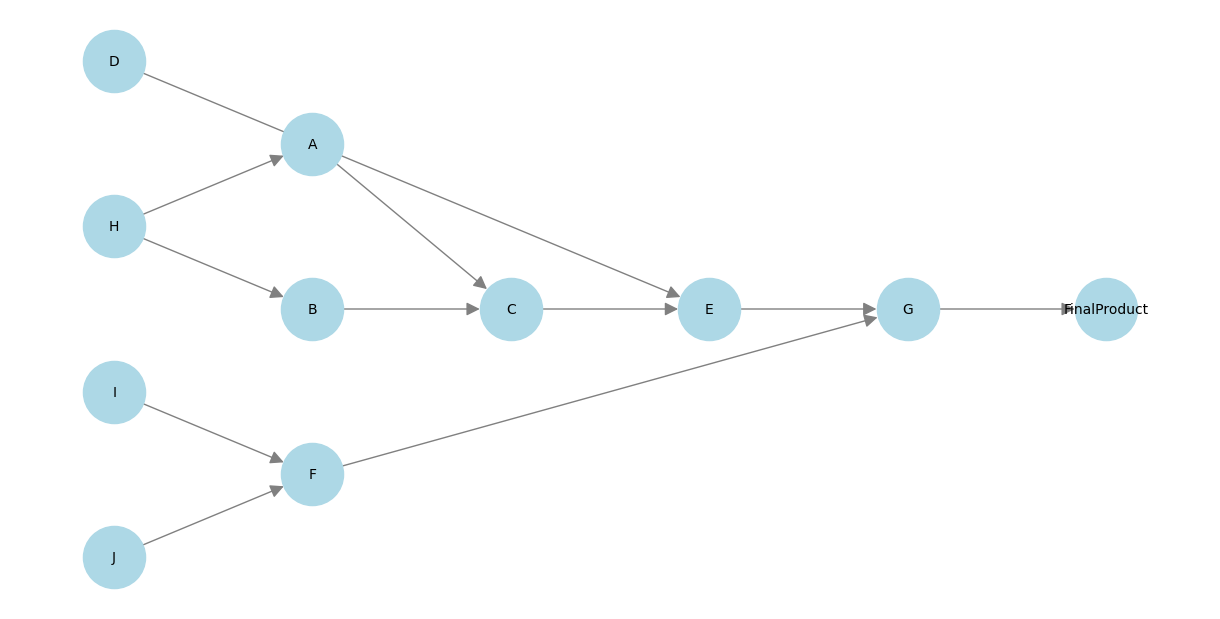

In [50]:
# 1) break G into topological generations (one list per “layer”)
layers = list(nx.topological_generations(G))

# 2) build a position dict that spaces each layer on the x‑axis,
#    and spreads nodes in that same layer along the y‑axis
pos = {}
for x, layer in enumerate(layers):
    n = len(layer)
    # center the layer at y=0, gap of 1
    y_start = (n - 1) / 2
    for i, node in enumerate(layer):
        pos[node] = (x, y_start - i)

# 3) draw with a bigger figure, arrows and labels
plt.figure(figsize=(12, 6))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    edge_color="gray",
    node_size=2000,
    font_size=10,
    arrowsize=20,
    arrowstyle='-|>'
)
plt.axis('off')
plt.tight_layout()
plt.show()

In [51]:
plan = [0,1,1,0,1,0,1,0,1,1,1,0,1,1,1,0,0,1]

In [52]:
print(list(nx.topological_sort(G)))

['D', 'H', 'I', 'J', 'A', 'B', 'F', 'C', 'E', 'G', 'FinalProduct']


In [53]:
test_process = ProductionProcess(ProductionGraph(G))

In [54]:
base_plan = test_process.create_production_plan(plan)
base_plan

[('D', 'Buy', 'ZF'),
 ('H', 'Buy', 'NCT'),
 ('H', 'Buy', 'NCT'),
 ('I', 'Buy', 'ZF'),
 ('J', 'Buy', 'NCT'),
 ('A', 'Produce', 'ZF'),
 ('B', 'Produce', 'NCT'),
 ('F', 'Produce', 'ZF'),
 ('C', 'Produce', 'NCT'),
 ('E', 'Produce', 'NCT'),
 ('G', 'Produce', 'NCT'),
 ('FinalProduct', 'Produce', 'ZF'),
 ('FinalProduct', 'Buy', 'NCT')]

In [55]:
test_planner = Planner(test_process)

base_plan = test_planner.create_production_plan(plan)
base_plan

[('D', 'Buy', 'ZF'),
 ('H', 'Buy', 'NCT'),
 ('H', 'Buy', 'NCT'),
 ('I', 'Buy', 'ZF'),
 ('J', 'Buy', 'NCT'),
 ('A', 'Produce', 'ZF'),
 ('B', 'Produce', 'NCT'),
 ('F', 'Produce', 'ZF'),
 ('C', 'Produce', 'NCT'),
 ('E', 'Produce', 'NCT'),
 ('G', 'Produce', 'NCT'),
 ('FinalProduct', 'Produce', 'ZF'),
 ('FinalProduct', 'Buy', 'NCT')]

In [56]:
test = test_planner.execute_plan(plan)
test

[(1, ('ZF', 'MKT'), 'Buy', 'D'),
 (2, ('NCT', 'MKT'), 'Buy', 'H'),
 (3, ('NCT', 'MKT'), 'Buy', 'H'),
 (4, ('ZF', 'MKT'), 'Buy', 'I'),
 (5, ('NCT', 'MKT'), 'Buy', 'J'),
 (6, ('ZF', 'NCT'), 'Buy', 'H'),
 (6, ('ZF',), 'Produce', 'A'),
 (7, ('NCT',), 'Produce', 'B'),
 (8, ('ZF', 'NCT'), 'Buy', 'J'),
 (8, ('ZF',), 'Produce', 'F'),
 (9, ('NCT', 'ZF'), 'Buy', 'A'),
 (9, ('NCT',), 'Produce', 'C'),
 (10, ('NCT', 'ZF'), 'Buy', 'D'),
 (10, ('NCT',), 'Produce', 'E'),
 (11, ('NCT', 'ZF'), 'Buy', 'F'),
 (11, ('NCT',), 'Produce', 'G'),
 (12, ('ZF', 'NCT'), 'Buy', 'G'),
 (12, ('ZF',), 'Produce', 'FinalProduct'),
 (13, ('NCT', 'ZF'), 'Buy', 'FinalProduct'),
 (14, ('MKT', 'NCT'), 'Buy', 'FinalProduct')]